# Numerische Integration


## Arbeitsblatt zur Einarbeitung - Lösungen


Dieses Arbeitsblatt soll durchgearbeitet werden, bevor mit der Vertiefung begonnen wird. Die Lösungen werden zwischen Freitag Abend und Montag Morgen hochgeladen.

Hier lernst du die numerische Integration kennen. Ziel ist es, das Integral einer analytisch gegebenen Funktion numerisch zu berechnen. Dies wirst du rudimentär implemntieren.

In der Vertiefung werden wir den Fall betrachten, dass nur Daten anstatt einer analytischen Funktion gegeben sind, und weitere Details diskutieren.


## Grundsätzliches Vorgehen


Das **bestimmte Integral** ist aus dem Modul **Analysis & Algebra** (1. Semester) bekannt. Eine kurze Wiederholung: Das unbestimmte Integral kehrt die Ableitung um, d.h. die Integration dient der Rekonstruktion einer Funktion aus ihrer Ableitung bis auf eine Konstante $C$:

$$
F'(x) = f(x) \qquad\Leftrightarrow\qquad \int f(x)\,dx = F(x) + C
$$

Das bestimmte Integral $\int_a^b f(x)\,dx$ kann weiter als die gerichtete Fläche zwischen dem Graphen von $f(x)$ und der $x$-Achse im Bereich $x\in[a,b]$ interpretiert werden. Der **Hauptsatz der Differential- und Integralrechnung** lässt uns ein bestimmtes Integral berechnen, wenn wir eine Stammfunktion $F(x)$ des Integranden kennen, also

$$ F'(x) = f(x) \qquad\Rightarrow\qquad \int_a^b f(x)\, dx = F(b) - F(a) $$

Die numerische Integration kommt dann zur Anwedung, wenn

-   der Integrand zwar als Funktion gegeben ist, dessen Stammfunktion jedoch nicht analytisch bestimmt werden kann. Beispiele:

    -   $ f(x) = \dfrac{\sin(x)}{x} $

    -   $ f(x) = \exp\left(-x^2\right) \quad $ (Gauss-Funktion)

-   das Integral im Prinzip analytisch integrierbar ist, die analytische Auswertung jedoch unverhältnismässig viel Rechenaufwand erfordert.

-   der Integrand nur punktweise gegeben ist, also als Datenreihe $(x_i, f(x_i))$, $i=0,\ldots,n-1$.


### Trapezregel


Eine einfache aber bereits recht gute Näherung des bestimmten Integrals erhält man mit der [Trapezregel](https://de.wikipedia.org/wiki/Trapezregel). Schaue dir eines der Erklärvideos an:

-   ["TRAPEZREGEL (Numerischer Integration)" - Mathe Peter](https://www.youtube.com/watch?v=BZbzdsvpc3c)
-   ["Näherungsformel zum Trapezverfahren, Numerische Integration" - Daniel Jung](https://www.youtube.com/watch?v=6hqHufW0dD4)


## Arbeitsauftrag


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1


#### a) Die Trapezregel


Notiere zuerst das grundsätzliches Vorgehen für die Anwendung der Trapezregel zur numerischen Integration. Schreibe auch die Formel für die Trapezregel auf, wie sie im [Video von Mathe Peter](https://www.youtube.com/watch?v=BZbzdsvpc3c) gegeben ist.


**Lösung:**

-   Zerlege das Intervall $[a,b]$ in $n$ gleich breite Intervalle.
-   Berechne Funktionswerte an den Intervallgrenzen und verbinde diese mit Geraden, so dass $n-1$ Trapeze entstehen.
-   Berechne die Flächen der Trapeze.
-   Die Summe aller Flächen ergibt eine Näherung des Integrals.
-   Je grösser $n$ desto genauer das Ergebnis.

$$
    T_n = \frac{h}{2} \left( f(a) + 2\sum_{i=1}^{n-1} f(a + ih) + f(b) \right)
    \,,\qquad\text{wobei}\quad h = \frac{b-a}{n}
$$


#### b) Trapezregel implementieren


Schreibe eine Funktion `trapezregel(f, a, b, n)` mit:

-   Argumente:
    -   `f`: die zu integrierende Funktion
    -   `a`: die untere Integrationsgrenze
    -   `b`: die obere Integrationsgrenze
    -   `n`: die Anzahl Trapeze.
-   Rückgabe:
    -   Näherungswert des bestimmten Integrals nach der Trapezregel.


In [2]:
def trapezregel(func, a, b, n):
    h = (b - a) / n
    s = sum([func(a + i * h) for i in range(1, n)])
    return (h / 2) * (func(a) + 2 * s + func(b))

#### c) Implementation testen


Berechne das folgende Integral mit deiner Funktion `trapezregel` und `n=4` Trapezen

$$
    \int_0^1 e^{x^2} \,dx
$$

Genau dieses Integral wird im [Video vom MathePeter](https://youtu.be/BZbzdsvpc3c) berechnet. Er findet das Resultat $\approx 1.4907$. Du auch?


In [3]:
def f(x):
    return np.exp(x**2)


trapezregel(f, 0, 1, 4)

np.float64(1.4906788616988553)

#### d) Darstellung

Hier soll eine Darstellung der bei der Trapezregel berechneten Trapez-Flächen und der eigentlichen Integral-Fläche entstehen.

1. Stelle $f(x)=\exp(x^2)$ im Bereich $x \in [-0.25, 1.25]$ grafisch dar.
2. Benutze die Funktion [`plt.fill_between`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html), um die Fläche zwischen $y=f(x)$ und der $x$-Achse im integrierten Bereich $x \in [0,1]$ einzufärben.
3. Füge die 5 linear verbundenen Punkte hinzu, die bei der Berechnng der Trapezregel mit `n=4` benutzt werden. (Dazu kannst du `plt.plot` und `plt.stem` kombinieren.)


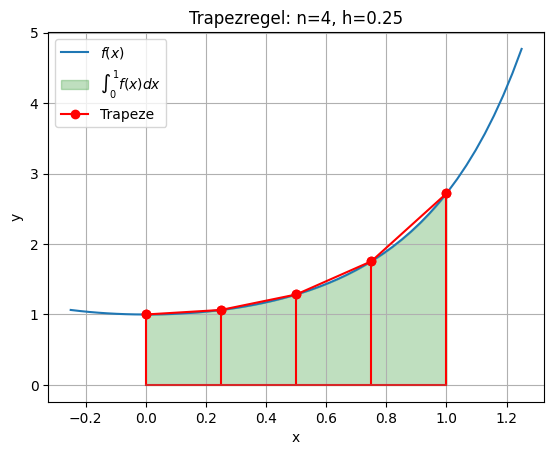

In [4]:
a = 0
b = 1
n = 4

x = np.linspace(a - 0.25, b + 0.25)
y = f(x)

x_ab = np.linspace(a, b)
y_ab = f(x_ab)

x_trapez = np.linspace(a, b, n + 1)
y_trapez = f(x_trapez)

plt.plot(x, y, label="$f(x)$")
plt.fill_between(x_ab, y_ab, alpha=0.25, color="green", label=r"$\int_0^1 f(x)dx$")
plt.stem(x_trapez, y_trapez, "ro-")
plt.plot(x_trapez, y_trapez, "ro-", label="Trapeze")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.title(f"Trapezregel: n={4}, h={1/n}")
plt.show()

### Aufgabe 2


#### a) Berechnung mit SciPy


Das Modul [`scipy.integrate`](https://docs.scipy.org/doc/scipy/reference/integrate.html) stellt Funktionen fürs Integrieren bereit. Wir benutzen [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) für die Integration von Funktionen.

Berechne das Integral mit [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html). Informiere dich über die Argumente und die Rückgabewerte in der Dokumentation.


In [5]:
from scipy.integrate import quad

quad(f, a, b)

(1.4626517459071817, 1.6238696453143372e-14)

#### b) Fehleranalyse


Berechne den absoluten Fehler, also die Differenz zwischen der selbst implementierten Funktion `trapezregel` und [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html). Der absolute Fehler soll positiv sein, wenn das Resultat von `trapezregel` grösser ist als das von SciPy.

-   Berechne diesen Fehler in Abhängigkeit von $n$ für $1\leq n \leq 100$.
-   Benutze [`plt.loglog`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.loglog.html), um die Fehler in einem doppelt logarithmischen Diagramm darzustellen. Alternativ kannst du auch [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) mit [`plt.xscale("log")`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html) und [`plt.yscale("log")`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html) benutzen.


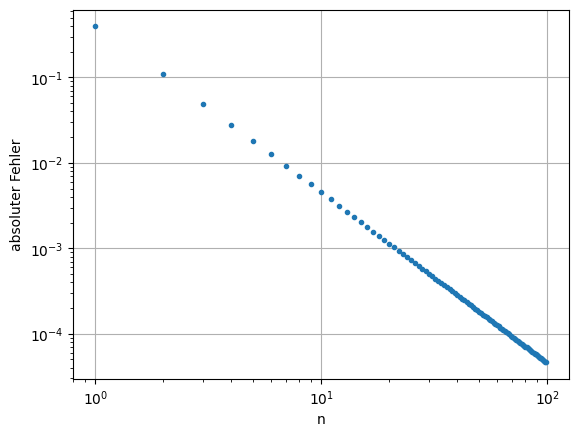

In [6]:
n_range = np.arange(1, 100)

reference = quad(f, a, b)[0]
error = np.array([trapezregel(f, a, b, n) - reference for n in n_range])

plt.loglog(n_range, error, ".")
plt.grid()
plt.xlabel("n")
plt.ylabel("absoluter Fehler")
plt.show()